# Exploratory Geochemical Visualisation

This notebook provides first-pass visual inspection of the compiled dataset before formal data filtering and machine learning. The aim is to visualise broad geochemical patterns using conventional REE and trace element normalised diagrams.

In [1]:
# =============================================================================
# Environment setup
# =============================================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

ROOT_DIR = Path.cwd().parent

DATA_DIR = ROOT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

DATA_FILE = RAW_DIR / "Data_Input.csv"

EXPORT_DIR = ROOT_DIR / "exports"
FIGURE_DIR = ROOT_DIR / "figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
EXPORT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

print("Environment initialised.")
print(f"Root directory   : {ROOT_DIR}")
print(f"Raw data         : {DATA_FILE}")
print(f"Processed data   : {PROCESSED_DIR}")
print(f"Export directory : {EXPORT_DIR}")
print(f"Figure directory : {FIGURE_DIR}")

Environment initialised.
Root directory   : C:\Users\d67199rs\Desktop\Lamproite
Raw data         : C:\Users\d67199rs\Desktop\Lamproite\data\raw\Data_Input.csv
Processed data   : C:\Users\d67199rs\Desktop\Lamproite\data\processed
Export directory : C:\Users\d67199rs\Desktop\Lamproite\exports
Figure directory : C:\Users\d67199rs\Desktop\Lamproite\figures


## 1. Import Dataset

Load the compiled geochemical dataset and calculate elemental K, P and Ti concentrations from oxide measurements.

In [2]:
# =============================================================================
# Import dataset
# =============================================================================

df = pd.read_csv(DATA_FILE, encoding="utf8")

df["Ti"] = df["TiO2"] * 0.5994 * 1e4
df["K"] = df["K2O"] * 0.8301 * 1e4
df["P"] = df["P2O5"] * 0.4364 * 1e4

print("Dataset successfully loaded.")
print(f"Rows   : {len(df)}")
print(f"Columns: {len(df.columns)}")

Dataset successfully loaded.
Rows   : 626
Columns: 51


## 2. Define Geochemical Variables

Define rare earth elements, primitive mantle normalised trace element order and metadata columns used for plotting.

In [3]:
# =============================================================================
# Define geochemical variables
# =============================================================================

REE = [
    "La", "Ce", "Pr", "Nd", "Sm", "Eu", "Gd",
    "Tb", "Dy", "Ho", "Er", "Tm", "Yb", "Lu"
]

TRACE_ELEMENTS = [
    "Cs", "Rb", "Ba", "Th", "U", "Nb", "Ta", "K",
    "La", "Ce", "Pb", "Pr", "Sr", "Nd", "P", "Sm",
    "Zr", "Hf", "Eu", "Ti", "Gd", "Tb", "Dy", "Y",
    "Ho", "Er", "Tm", "Yb", "Lu"
]

META = ["Series", "Location", "Rock Type"]

print(f"REE elements          : {len(REE)}")
print(f"Trace element sequence: {len(TRACE_ELEMENTS)}")

REE elements          : 14
Trace element sequence: 29


In [4]:
# =============================================================================
# Reference values for normalisation
# =============================================================================
# Source: Sun and McDonough (1989)

CI_REE = pd.Series({
    "La": 0.237,
    "Ce": 0.612,
    "Pr": 0.095,
    "Nd": 0.467,
    "Sm": 0.153,
    "Eu": 0.058,
    "Gd": 0.2055,
    "Tb": 0.0374,
    "Dy": 0.2540,
    "Ho": 0.0566,
    "Er": 0.1655,
    "Tm": 0.0255,
    "Yb": 0.170,
    "Lu": 0.0254
})

PM_TRACE = pd.Series({
    "Cs": 0.032,
    "Rb": 0.635,
    "Ba": 6.989,
    "Th": 0.085,
    "U": 0.021,
    "Nb": 0.713,
    "Ta": 0.041,
    "K": 250,
    "La": 0.687,
    "Ce": 1.775,
    "Pb": 0.185,
    "Pr": 0.276,
    "Sr": 21.1,
    "Nd": 1.354,
    "P": 95,
    "Sm": 0.444,
    "Zr": 11.2,
    "Hf": 0.309,
    "Eu": 0.168,
    "Ti": 1300,
    "Gd": 0.596,
    "Tb": 0.108,
    "Dy": 0.737,
    "Y": 4.55,
    "Ho": 0.164,
    "Er": 0.480,
    "Tm": 0.074,
    "Yb": 0.493,
    "Lu": 0.074
})

print("Reference values loaded from Sun and McDonough (1989).")
print(f"CI REE values: {len(CI_REE)}")
print(f"Primitive mantle values: {len(PM_TRACE)}")

Reference values loaded from Sun and McDonough (1989).
CI REE values: 14
Primitive mantle values: 29


## 3. Dataset Structure

Summarise the distribution of analyses across geological series and locations before plotting. This provides context for interpreting the normalised diagrams.

In [5]:
# =============================================================================
# Dataset structure
# =============================================================================

location_summary = (
    df.groupby(["Series", "Location"])
    .size()
    .reset_index(name="Analyses")
    .sort_values(["Series", "Analyses"], ascending=[True, False])
)

series_summary = (
    df.groupby("Series")
    .agg(
        Analyses=("Series", "size"),
        Locations=("Location", "nunique")
    )
)

print("=" * 70)
print("SERIES SUMMARY")
print("=" * 70)
display(series_summary)

print("=" * 70)
print("LOCATION SUMMARY")
print("=" * 70)
display(location_summary)

SERIES SUMMARY


,Analyses,Locations
Series,,
Anorogenic,216,10
Orogenic,410,16


LOCATION SUMMARY


,Series,Location,Analyses
1,Anorogenic,Australia,101
0,Anorogenic,Antarctica,22
6,Anorogenic,USA (Kansas),22
3,Anorogenic,India,21
4,Anorogenic,Norway,14
2,Anorogenic,China (Yangtze Block),13
5,Anorogenic,Russia,9
7,Anorogenic,"USA (Leucite Hills, Wyoming)",6
9,Anorogenic,Zambia,6
8,Anorogenic,Utah (USA),2


## 4. Chondrite-normalised REE & Primitive Mantle-normalised Trace Element Diagrams

Rare earth element concentrations are normalised to C1 chondrite & Trace element concentrations are normalised to primitive mantle values from Sun and McDonough (1989). Median values are plotted by geological series, with shaded envelopes showing the observed minimum to maximum range for each element. 

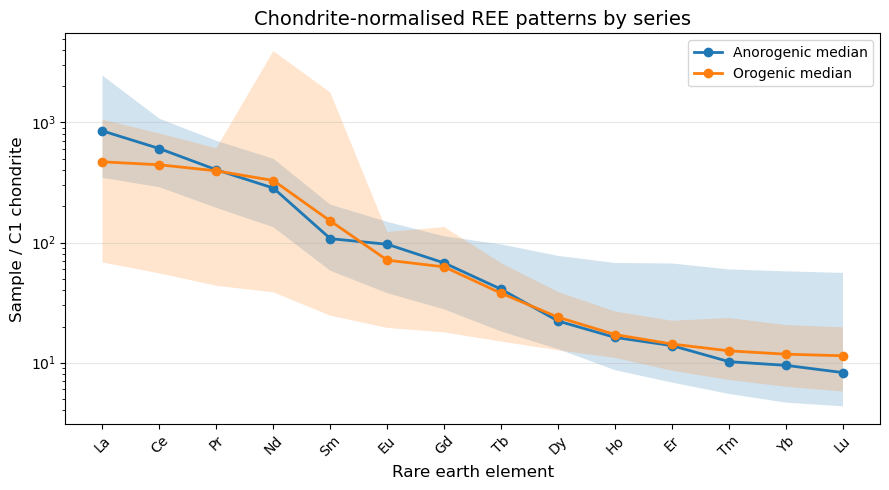

Saved: C:\Users\d67199rs\Desktop\Lamproite\figures\01_REE_chondrite_by_series.png


In [6]:
# =============================================================================
# Chondrite-normalised REE diagram by series
# =============================================================================

ree_df = df[META + REE].dropna(subset=REE).copy()
ree_norm = ree_df.copy()

for el in REE:
    ree_norm[el] = ree_norm[el] / CI_REE[el]

fig, ax = plt.subplots(figsize=(9, 5))

for series, sub in ree_norm.groupby("Series"):
    values = sub[REE]
    median = values.median()
    lo = values.min()
    hi = values.max()

    ax.plot(REE, median.values, marker="o", linewidth=2, label=f"{series} median")
    ax.fill_between(REE, lo.values, hi.values, alpha=0.2)

ax.set_yscale("log")
ax.set_xlabel("Rare earth element", fontsize=12)
ax.set_ylabel("Sample / C1 chondrite", fontsize=12)
ax.set_title("Chondrite-normalised REE patterns by series", fontsize=14)
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()

outpath = FIGURE_DIR / "01_REE_chondrite_by_series.png"
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {outpath}")

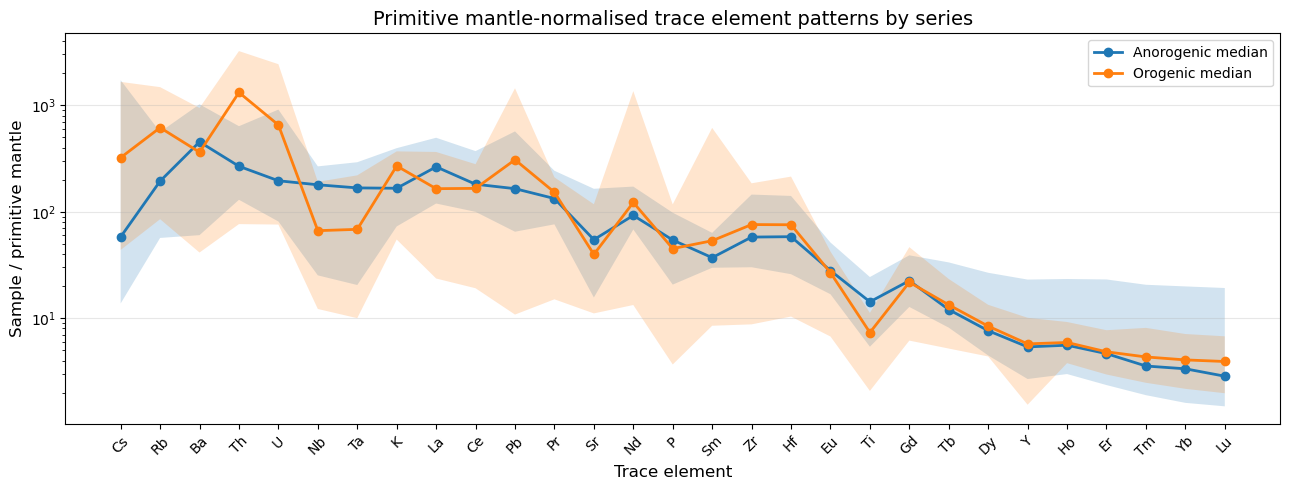

Saved: C:\Users\d67199rs\Desktop\Lamproite\figures\02_PM_trace_element_by_series.png


In [7]:
# =============================================================================
# Primitive mantle-normalised trace element diagram by series
# =============================================================================

te_df = df[META + TRACE_ELEMENTS].dropna(subset=TRACE_ELEMENTS).copy()
te_norm = te_df.copy()

for el in TRACE_ELEMENTS:
    te_norm[el] = te_norm[el] / PM_TRACE[el]

fig, ax = plt.subplots(figsize=(13, 5))

for series, sub in te_norm.groupby("Series"):
    values = sub[TRACE_ELEMENTS]
    median = values.median()
    lo = values.min()
    hi = values.max()

    ax.plot(TRACE_ELEMENTS, median.values, marker="o", linewidth=2, label=f"{series} median")
    ax.fill_between(TRACE_ELEMENTS, lo.values, hi.values, alpha=0.2)

ax.set_yscale("log")
ax.set_xlabel("Trace element", fontsize=12)
ax.set_ylabel("Sample / primitive mantle", fontsize=12)
ax.set_title("Primitive mantle-normalised trace element patterns by series", fontsize=14)
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()

outpath = FIGURE_DIR / "02_PM_trace_element_by_series.png"
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {outpath}")

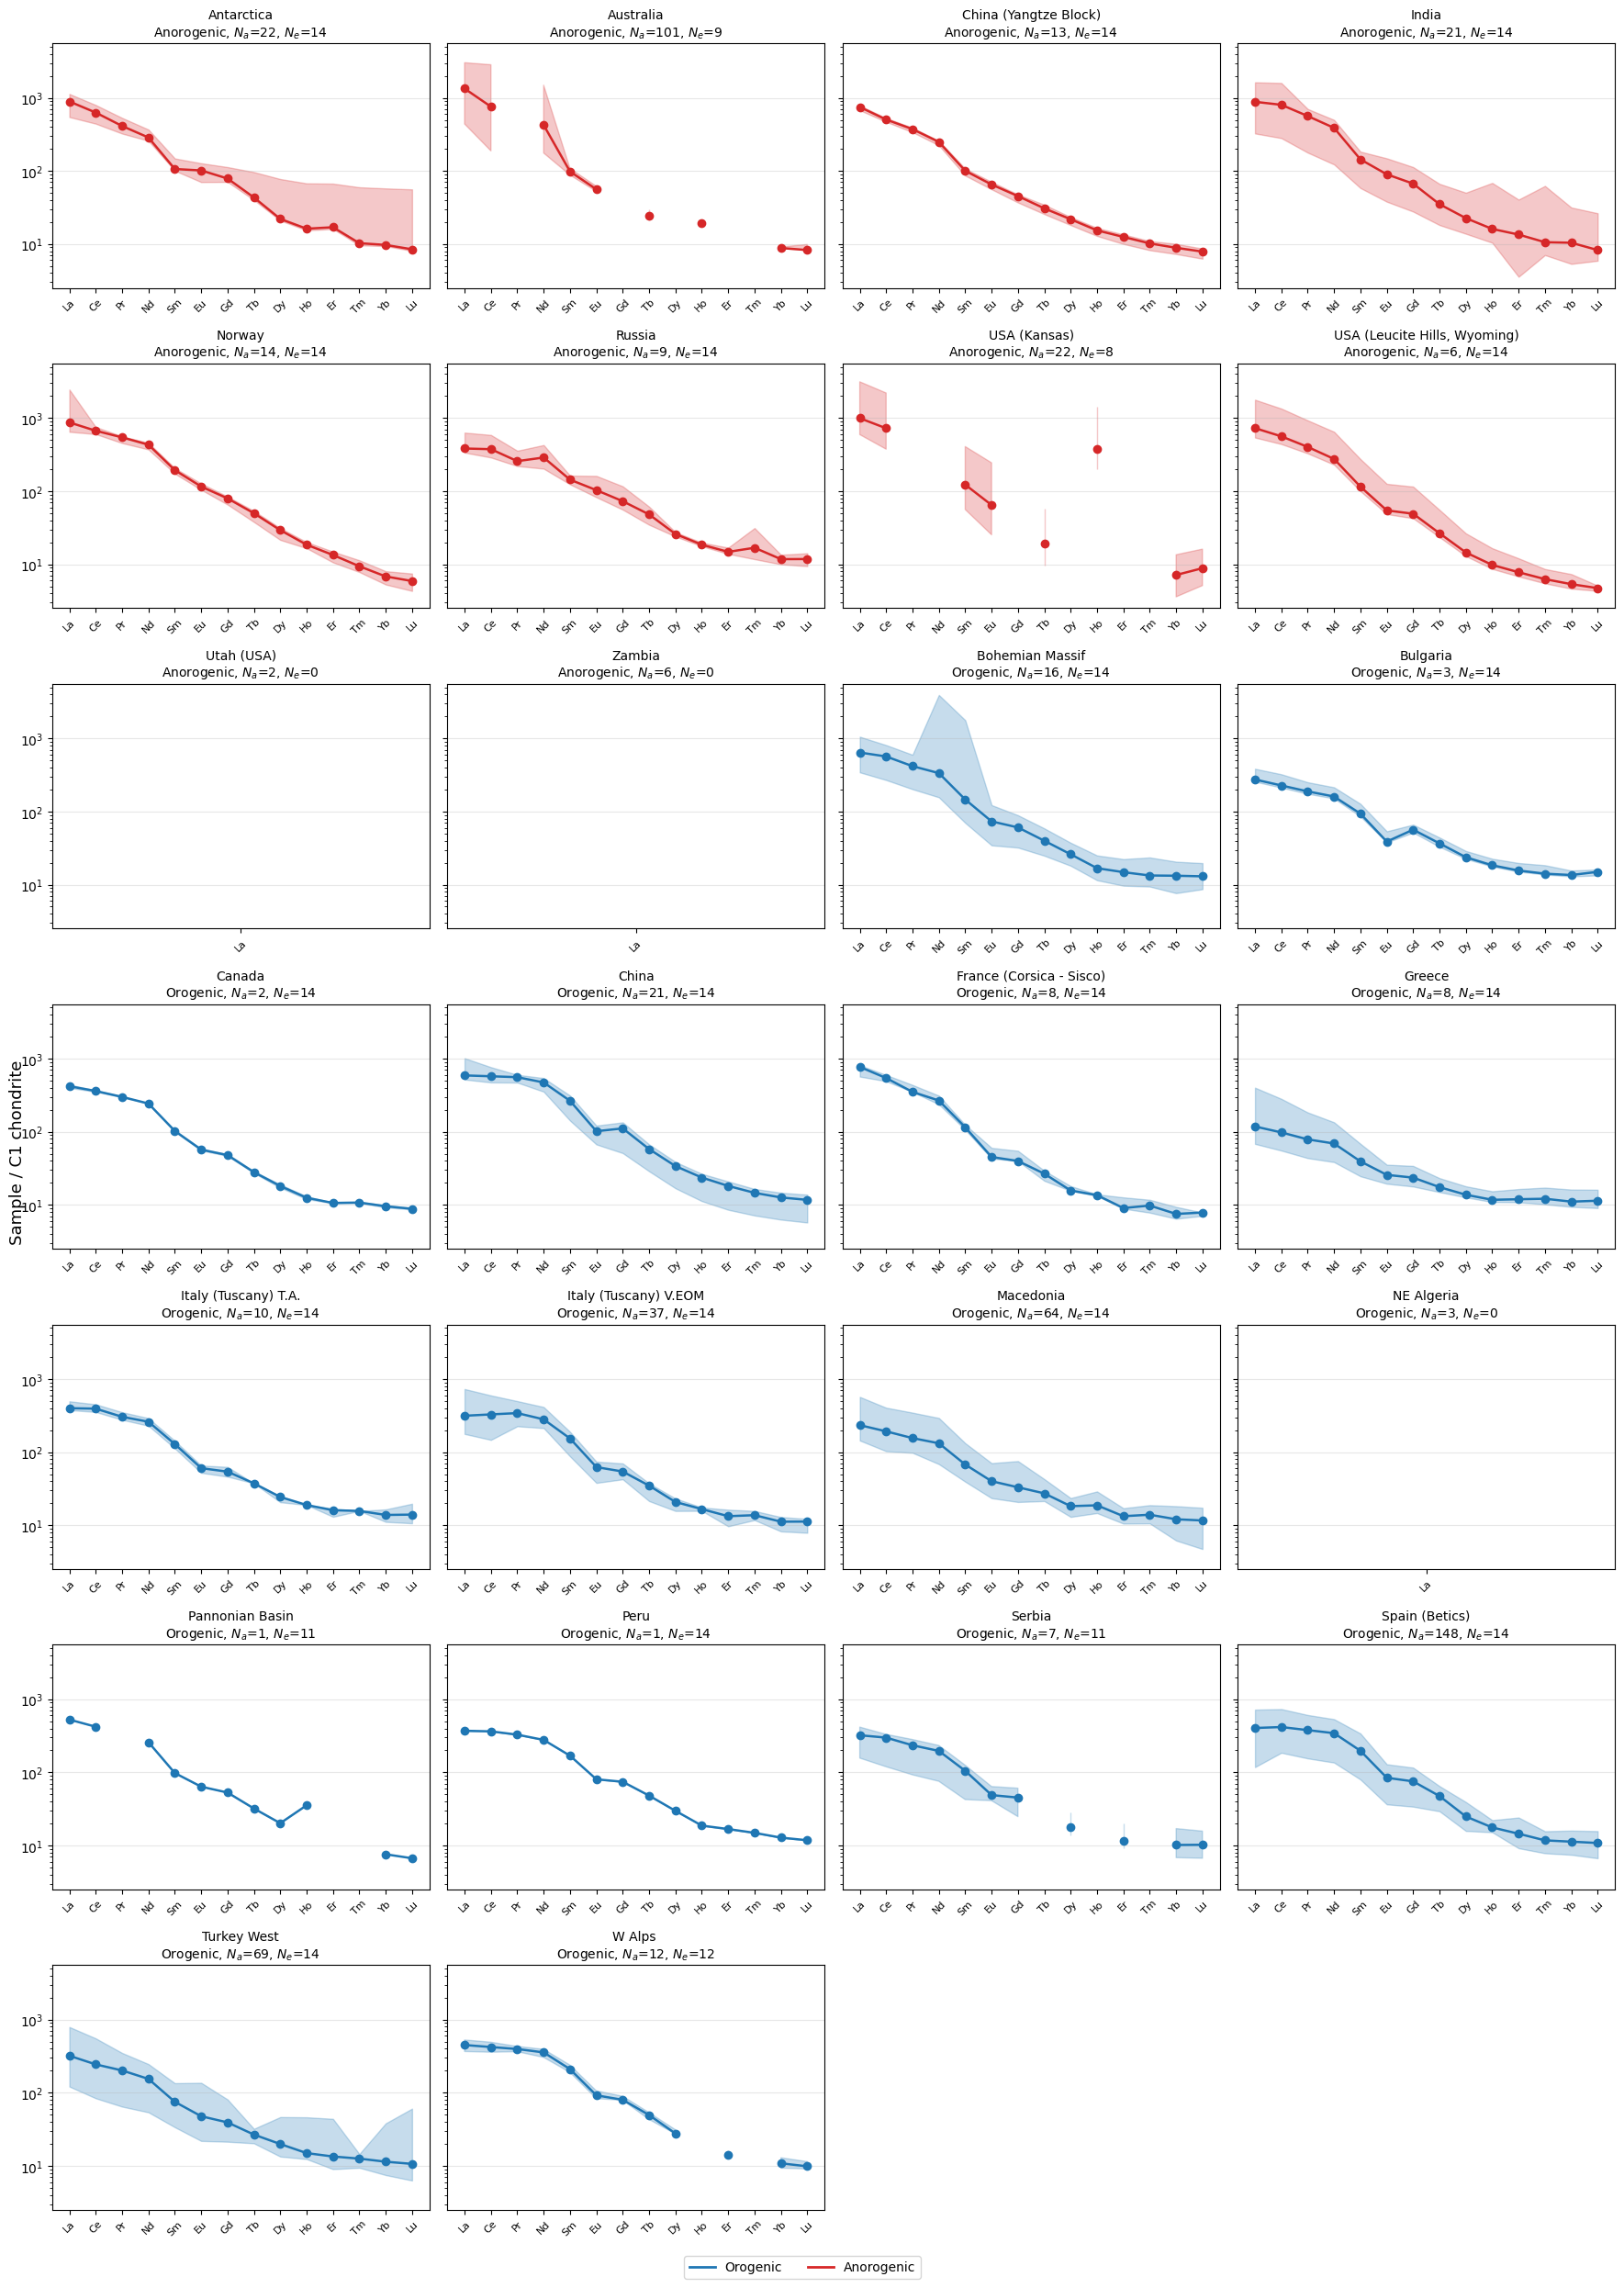

Saved: C:\Users\d67199rs\Desktop\Lamproite\figures\03_REE_chondrite_multipanel_locations.png


In [8]:
# =============================================================================
# Chondrite-normalised REE patterns by location
# =============================================================================

plot_df = df[META + REE].copy()

for el in REE:
    plot_df[el] = plot_df[el] / CI_REE[el]

panel_rows = (
    plot_df[["Series", "Location"]]
    .drop_duplicates()
    .sort_values(["Series", "Location"])
)

panel_rows = list(panel_rows.itertuples(index=False, name=None))

ncols = 4
n_panels = len(panel_rows)
nrows = int(np.ceil(n_panels / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(4.5 * ncols, 3.6 * nrows),
    sharey=True
)

axes = np.array(axes).flatten()

series_colours = {
    "Orogenic": "tab:blue",
    "Anorogenic": "tab:red"
}

for ax, (series, location) in zip(axes, panel_rows):

    sub = plot_df[
        (plot_df["Series"] == series) &
        (plot_df["Location"] == location)
    ]

    median = sub[REE].median()
    lo = sub[REE].min()
    hi = sub[REE].max()

    colour = series_colours[series]

    ax.plot(REE, median, color=colour, marker="o", linewidth=1.8)
    ax.fill_between(REE, lo, hi, color=colour, alpha=0.25)

    n_rows = len(sub)
    n_elements = sub[REE].notna().any(axis=0).sum()

    ax.set_title(
        rf"{location}" "\n"
        rf"{series}, $N_{{a}}$={n_rows}, $N_{{e}}$={n_elements}",
        fontsize=10
    )

    ax.set_yscale("log")
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.grid(axis="y", alpha=0.3)

for ax in axes[n_panels:]:
    ax.remove()

fig.supylabel("Sample / C1 chondrite", fontsize=13)

legend_handles = [
    Line2D([0], [0], color="tab:blue", lw=2, label="Orogenic"),
    Line2D([0], [0], color="tab:red", lw=2, label="Anorogenic")
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=2,
    frameon=True,
    bbox_to_anchor=(0.5, 0.01)
)

plt.tight_layout(rect=[0.0, 0.025, 1, 1])

outpath = FIGURE_DIR / "03_REE_chondrite_multipanel_locations.png"
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {outpath}")

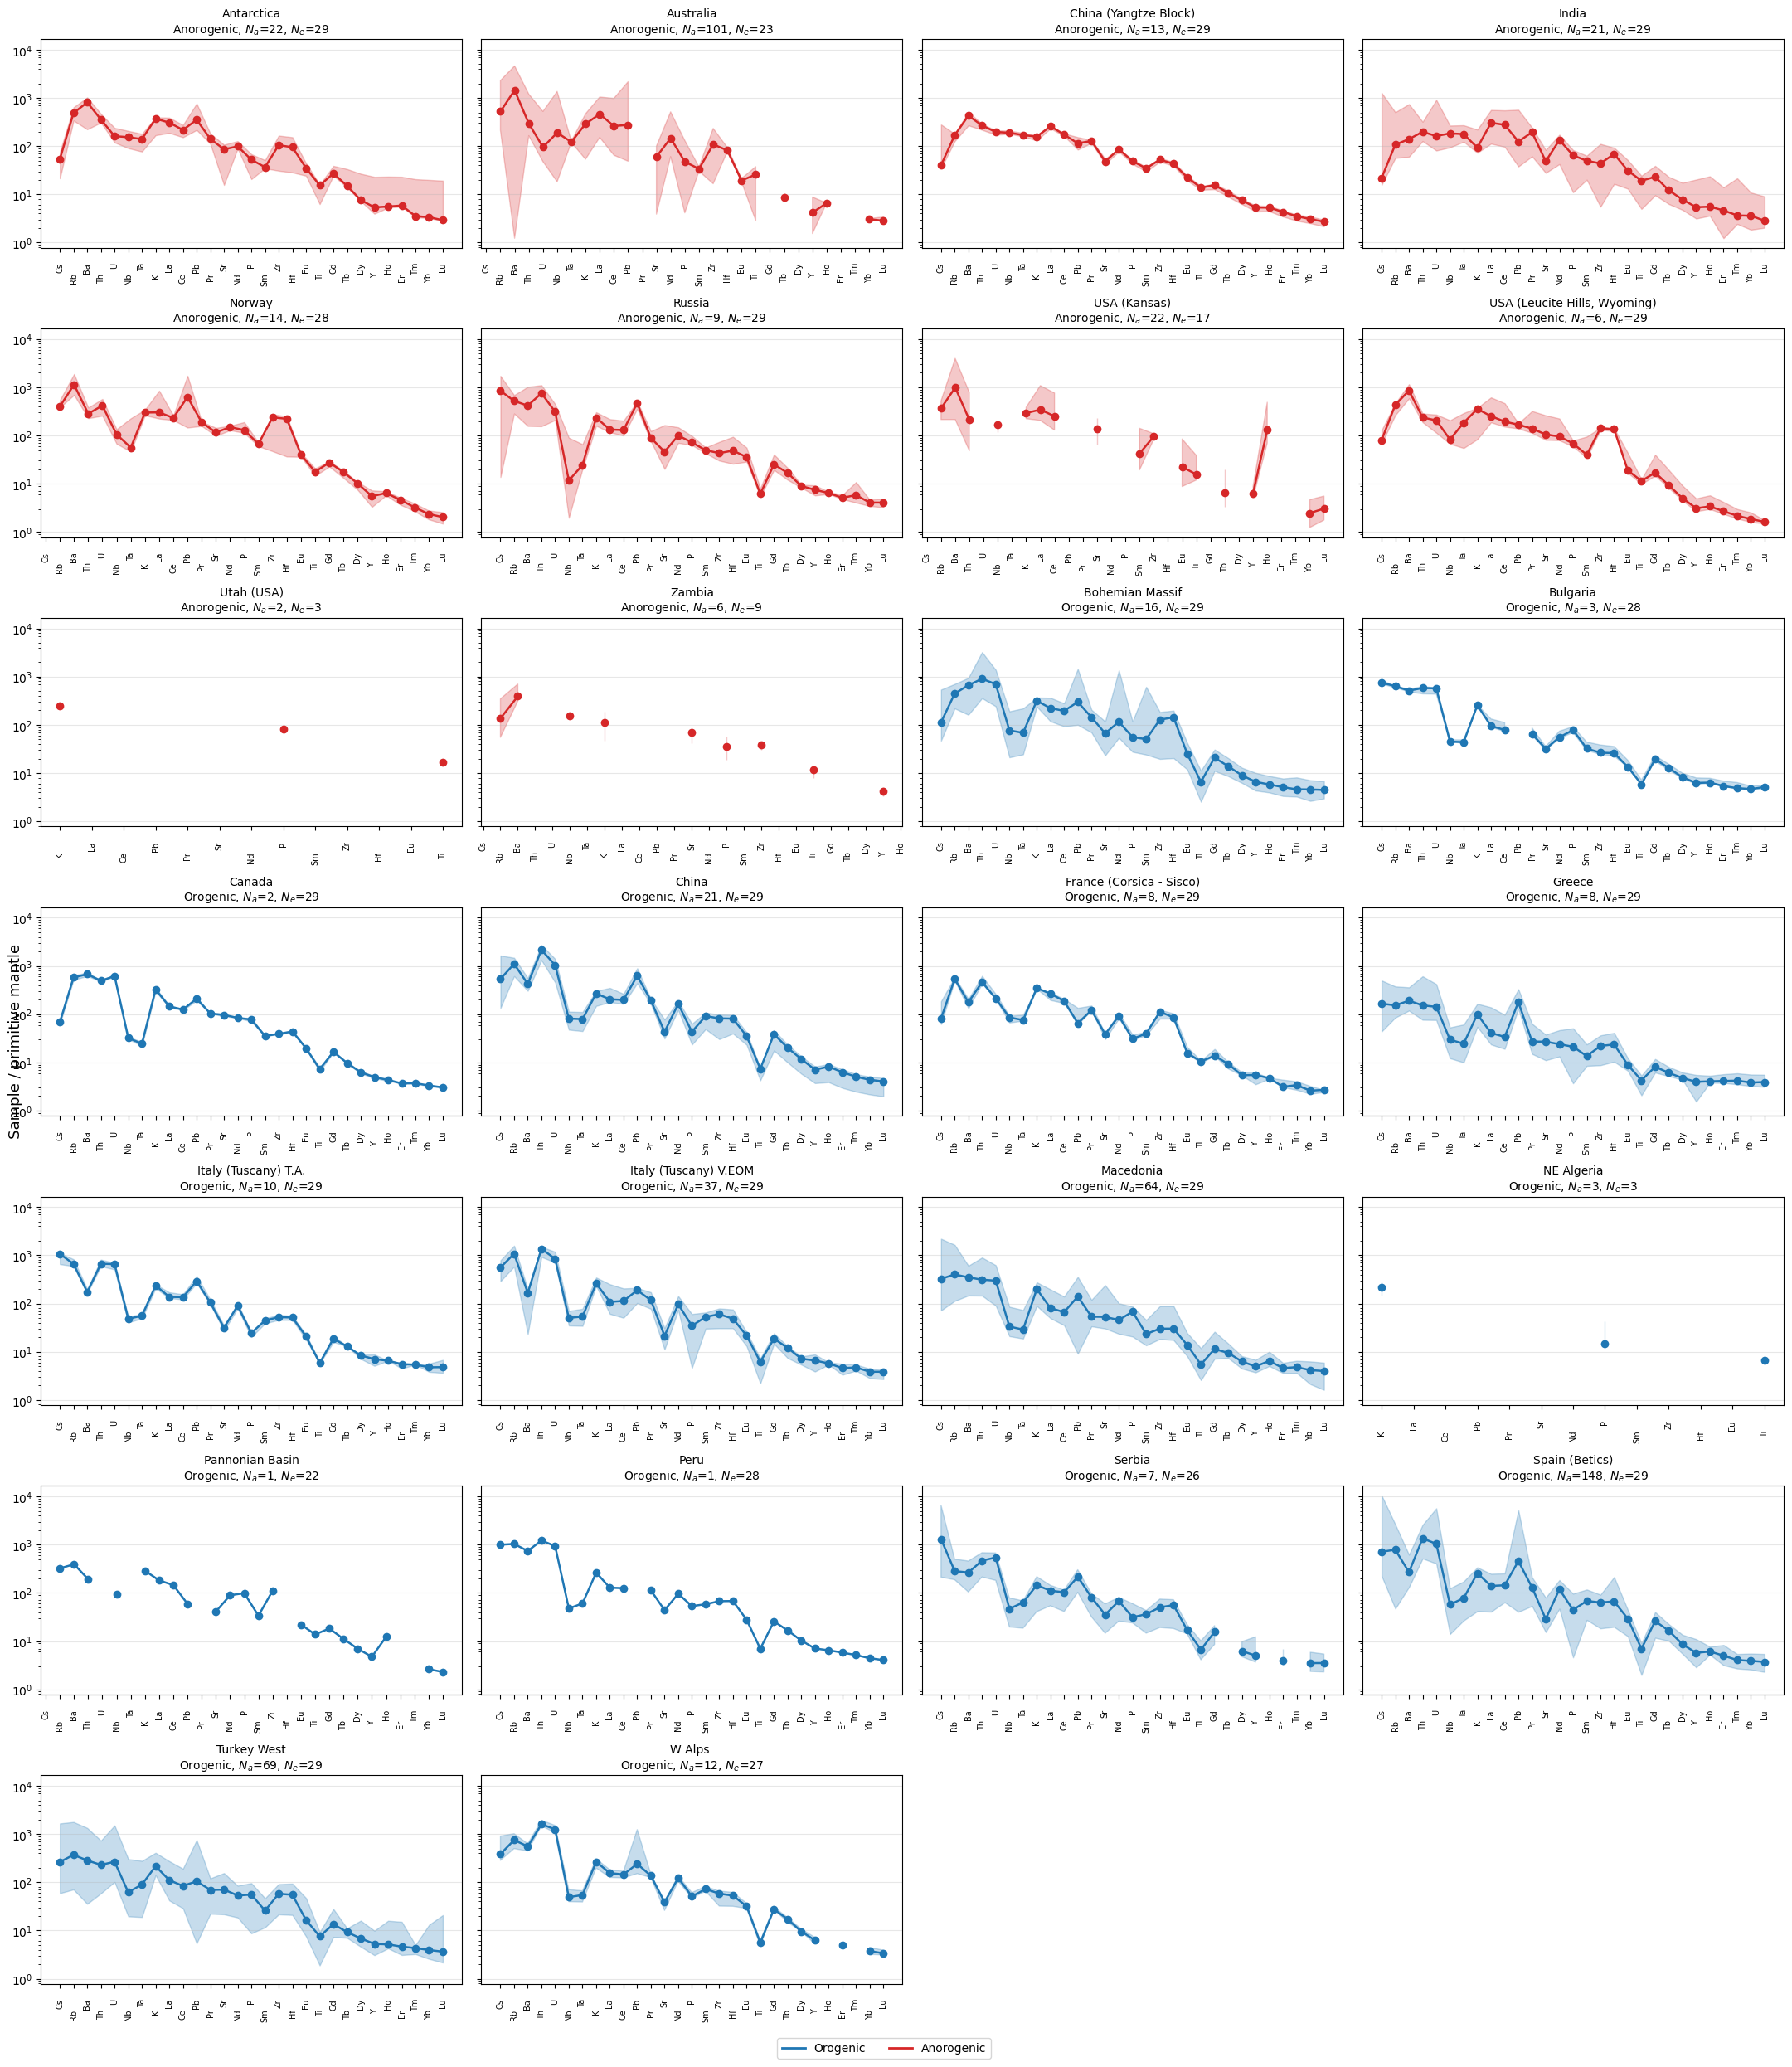

Saved: C:\Users\d67199rs\Desktop\Lamproite\figures\04_PM_trace_multipanel_locations.png


In [9]:
# =============================================================================
# Primitive mantle-normalised trace element patterns by location
# =============================================================================

plot_df = df[META + TRACE_ELEMENTS].copy()

for el in TRACE_ELEMENTS:
    plot_df[el] = plot_df[el] / PM_TRACE[el]

panel_rows = (
    plot_df[["Series", "Location"]]
    .drop_duplicates()
    .sort_values(["Series", "Location"])
)

panel_rows = list(panel_rows.itertuples(index=False, name=None))

ncols = 4
n_panels = len(panel_rows)
nrows = int(np.ceil(n_panels / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5.5* ncols, 3.6 * nrows),   # wider than REE
    sharey=True
)

axes = np.array(axes).flatten()

series_colours = {
    "Orogenic": "tab:blue",
    "Anorogenic": "tab:red"
}

for ax, (series, location) in zip(axes, panel_rows):

    sub = plot_df[
        (plot_df["Series"] == series) &
        (plot_df["Location"] == location)
    ]

    median = sub[TRACE_ELEMENTS].median()
    lo = sub[TRACE_ELEMENTS].min()
    hi = sub[TRACE_ELEMENTS].max()

    colour = series_colours[series]

    ax.plot(TRACE_ELEMENTS, median, color=colour, marker="o", linewidth=1.8)
    ax.fill_between(TRACE_ELEMENTS, lo, hi, color=colour, alpha=0.25)

    n_rows = len(sub)
    n_elements = sub[TRACE_ELEMENTS].notna().any(axis=0).sum()

    ax.set_title(
        rf"{location}" "\n"
        rf"{series}, $N_{{a}}$={n_rows}, $N_{{e}}$={n_elements}",
        fontsize=10
    )

    ax.set_yscale("log")
    ax.tick_params(axis="x", rotation=90, labelsize=7)
    for i, label in enumerate(ax.get_xticklabels()):
        if i % 2 == 0:
            label.set_y(-0.03)   # slightly higher
        else:
            label.set_y(-0.08)   # slightly lower
        ax.grid(axis="y", alpha=0.3)
    
for ax in axes[n_panels:]:
        ax.remove()

fig.supylabel("Sample / primitive mantle", fontsize=13)

legend_handles = [
    Line2D([0], [0], color="tab:blue", lw=2, label="Orogenic"),
    Line2D([0], [0], color="tab:red", lw=2, label="Anorogenic")
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=2,
    frameon=True,
    bbox_to_anchor=(0.5, 0.01)
)

plt.tight_layout(rect=[0.0, 0.025, 1, 1])

outpath = FIGURE_DIR / "04_PM_trace_multipanel_locations.png"
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {outpath}")